The listed packages are essential for executing the code required for this assignment, which is why they were imported.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import math
import statsmodels.formula.api as smf 
import statsmodels.stats.api as sms
import scipy.stats as stats
import linearmodels.iv as iv
import linearmodels as plm

import os
import sys

In [2]:
#Selecting a random hour and creating a new dataset with data for only that hour
randhour= 9

In [3]:
#read datafile
df = pd.read_csv('elmarket.csv', parse_dates= ['time', 'date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35112 entries, 0 to 35111
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   time        35112 non-null  datetime64[ns]
 1   date        35112 non-null  datetime64[ns]
 2   year        35112 non-null  int64         
 3   week        35112 non-null  int64         
 4   day         35112 non-null  int64         
 5   hour        35112 non-null  int64         
 6   price       35112 non-null  float64       
 7   cons        35112 non-null  int64         
 8   prod        35112 non-null  int64         
 9   res_level   35112 non-null  int64         
 10  norm_level  35112 non-null  int64         
 11  se_nuc      35112 non-null  int64         
 12  p_oil       35112 non-null  float64       
 13  p_co2       35112 non-null  float64       
 14  temp_osl    35112 non-null  float64       
 15  dholi       35112 non-null  int64         
 16  dwkday      35112 non-

In [4]:

df

,time,date,year,week,day,hour,price,cons,prod,res_level,norm_level,se_nuc,p_oil,p_co2,temp_osl,dholi,dwkday
0,2006-01-09 00:00:00,2006-01-09,2006,2,1,0,39.17,12130,11941,4211,3602,96,442.85,251.26,-2.5,0,1
1,2006-01-09 01:00:00,2006-01-09,2006,2,1,1,38.63,11845,10796,4211,3602,96,442.85,251.26,-2.5,0,1
2,2006-01-09 02:00:00,2006-01-09,2006,2,1,2,38.01,11706,10213,4211,3602,96,442.85,251.26,-2.5,0,1
3,2006-01-09 03:00:00,2006-01-09,2006,2,1,3,37.81,11700,9989,4211,3602,96,442.85,251.26,-2.5,0,1
4,2006-01-09 04:00:00,2006-01-09,2006,2,1,4,38.21,11843,10532,4211,3602,96,442.85,251.26,-2.7,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35107,2010-01-10 19:00:00,2010-01-10,2010,1,7,19,49.23,18684,16535,3633,3827,66,451.60,124.90,-13.1,0,0
35108,2010-01-10 20:00:00,2010-01-10,2010,1,7,20,46.56,18573,15267,3633,3827,66,451.60,124.90,-13.8,0,0
35109,2010-01-10 21:00:00,2010-01-10,2010,1,7,21,45.98,18242,14352,3633,3827,67,451.60,124.90,-15.0,0,0
35110,2010-01-10 22:00:00,2010-01-10,2010,1,7,22,45.37,17759,13322,3633,3827,66,451.60,124.90,-14.6,0,0


In [5]:
#selecting observations only for a specific hour
df = df[df["hour"] == randhour]
##set index and sort
df = df.set_index(["date"]).sort_index().copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1463 entries, 2006-01-09 to 2010-01-10
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   time        1463 non-null   datetime64[ns]
 1   year        1463 non-null   int64         
 2   week        1463 non-null   int64         
 3   day         1463 non-null   int64         
 4   hour        1463 non-null   int64         
 5   price       1463 non-null   float64       
 6   cons        1463 non-null   int64         
 7   prod        1463 non-null   int64         
 8   res_level   1463 non-null   int64         
 9   norm_level  1463 non-null   int64         
 10  se_nuc      1463 non-null   int64         
 11  p_oil       1463 non-null   float64       
 12  p_co2       1463 non-null   float64       
 13  temp_osl    1463 non-null   float64       
 14  dholi       1463 non-null   int64         
 15  dwkday      1463 non-null   int64         
dtypes: dat

# QUESTION 1.1 

# Taking Log transformations of prices and quantities

In [6]:
# Applying log transformations
df["log_price"] = np.log(df["price"])
df["log_cons"] = np.log(df["cons"])
df["log_prod"] = np.log(df["prod"])
df["ln_poil"] = np.log(df["p_oil"])
df["ln_pco2"] = np.log(df["p_co2"])
# Verifying transformations
df[["log_price", "log_cons", "log_prod", "ln_poil", "ln_pco2"]].head()


,log_price,log_cons,log_prod,ln_poil,ln_pco2
date,,,,,
2006-01-09,3.844600,9.619200,9.763593,6.093231,5.526488
2006-01-10,3.718924,9.571226,9.690171,6.097220,5.520260
2006-01-11,3.681099,9.488124,9.474933,6.088954,5.530738
2006-01-12,3.702782,9.484177,9.533944,6.115451,5.533073
2006-01-13,3.696848,9.507775,9.598659,6.095870,5.531134


# Question 1.2.1 Creating a plot for electricity price

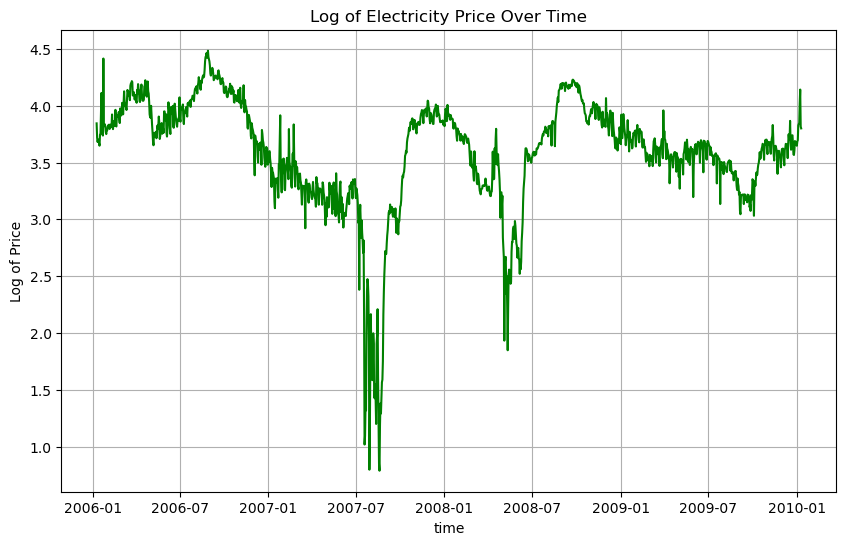

In [7]:
# Electricty Price Plot
plt.figure(figsize = (10,6))
plt.plot(df["time"], df["log_price"], color = "green")
plt.title("Log of Electricity Price Over Time")
plt.xlabel("time")
plt.ylabel("Log of Price")
plt.grid(True)
plt. show ()

The prices of electricity witnessed a sharp decline in mid-2007, and after this dip there is a rapid increase back to the previous level. Then around mid-2008, the prices of electricity also drop gadually but not as low as the same period in the previous year. The large drop in the prices may be attributed to variations in weather where there is a difference in the amount of precipitation, which caterted for that drop. There might have experienced a lot of rain during the summer, and the prices were almost negative. Moving on to the mid-2008 we notice that even though the prices decreased, there werent as low as the previous year. We may assume that there was less precipitation hence the reservior was almost dry. After this dip, the prices remain relatively stable.

# Question 1.2.2 Creating a plot for consumption

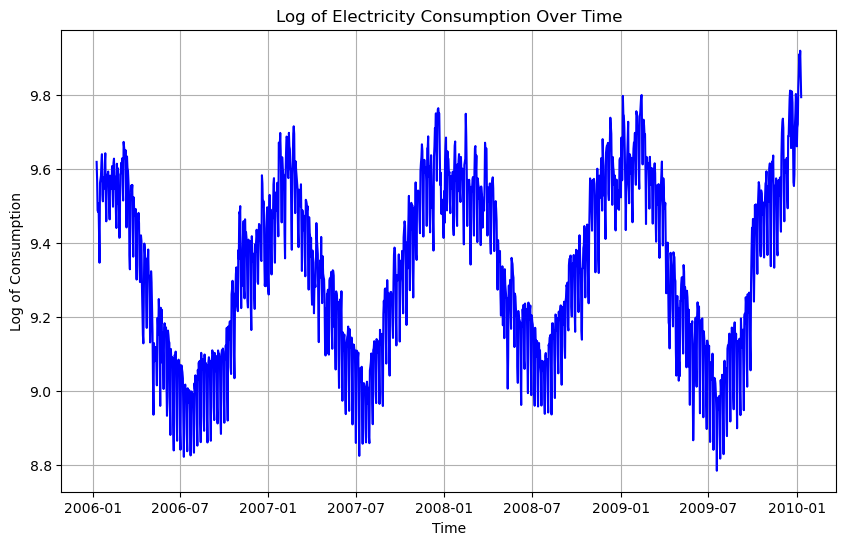

In [8]:
# Consumption Plot
plt.figure(figsize=(10, 6))
plt.plot (df["time"], df["log_cons"], color = "blue")
plt.title("Log of Electricity Consumption Over Time")
plt.xlabel('Time')
plt.ylabel("Log of Consumption")
plt.grid(True)
plt.show()

The electricity consumption has a distinct seasonal trend, with regular peaks and troughs occurring throughout the time series. This is likely linked to heightened energy demand during extreme temperatures, whether for heating in the winter or cooling in the summer. The lowest points in consumption occur around the same time each year, indicating a seasonal decline in demand. The decrease in consumption which occurs around the same period each year (during the mid year) may be attributed to the summer period where there is less reliance on electricity for heating. After this period the consumption starts to increase as temperatures begin to drop. The increase in consumption occurs during winter period because people demand more electricity for heating purposes. 


# Question 1.2.3 Creating a plot for Electricity Production 

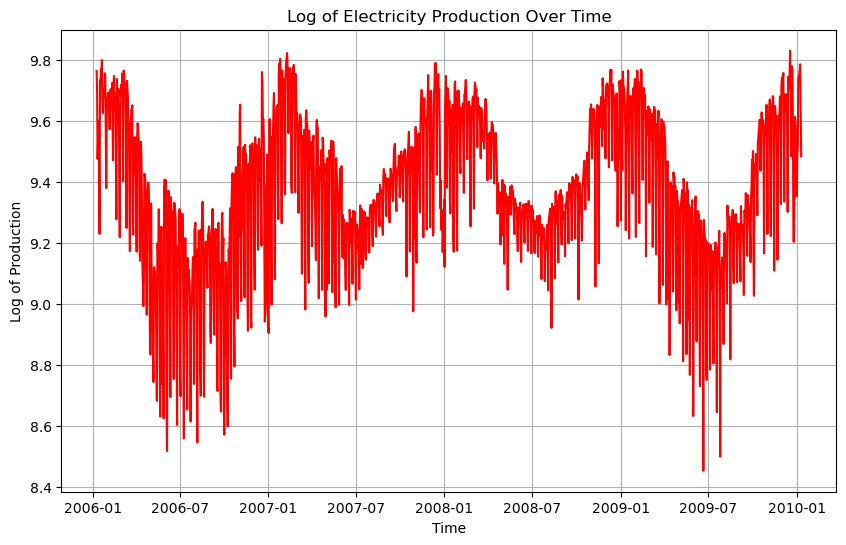

In [9]:

# Production Plot
plt. figure(figsize=(10, 6))
plt.plot(df["time"], df["log_prod"], color="red")
plt.title("Log of Electricity Production Over Time")
plt.xlabel('Time')
plt.ylabel('Log of Production')
plt. grid(True)
plt.show ()

The generation of electricity fluctuates throughout the year in line with seasonal variations in consumption, as depicted in the graph above. 
The recurring pattern of peaks and troughs sugges tthat thn electricity generatiny aignss with demand fluctuatios for both summer and winter periods.nThe former is associated with a decrease in electricity production whilst the latter results in more electricity produced hence the pattern. 

Over the span of four years, the overall trend appears relatively stable, with no significant long-term increases or decreain the heslog in protion. d. This implies that production capacity and demand have remained relatively unchanged during this ioer .

Similar to consumption trends, there is a noticeable decreasmid-late 2008,h indicates nify a response to reduced devels.

# Question 1.3 Plot price against consumption.

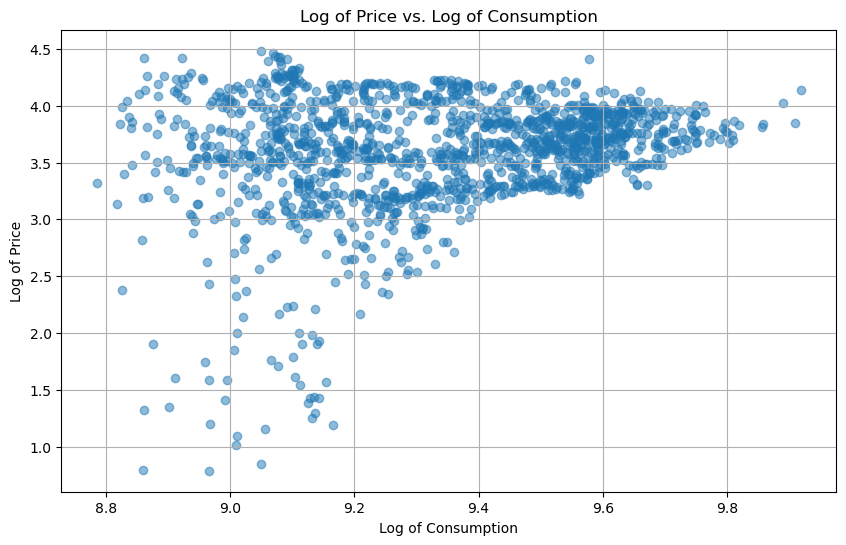

In [10]:
# Price vs. Consumption Plot
plt.figure(figsize= (10, 6))
plt.scatter (df["log_cons"], df["log_price"], alpha=0.5)
plt.title("Log of Price vs. Log of Consumption")
plt.xlabel("Log of Consumption")
plt.ylabel('Log of Price')
plt.grid(True)
plt.show ()

There is a wide dispersion of points which suggests that the relationship between log price and log consumption lacks strong linearity. This may mean that the price elasticity of electricity varies across different consumption levels. It is also important to note that there are several points concentrated around the middle of the consumption range, indicating that most data points fall within a central band of consumption value. As consumption increases, the points cluster together around the prices 3.5 to 4.5 and forms sort sort of a funnel.The spread of points vertically at each level of consumption suggests that there can be significant variations in price even when consumption is relatively stable.n

# Question 1.4 Plot price against production

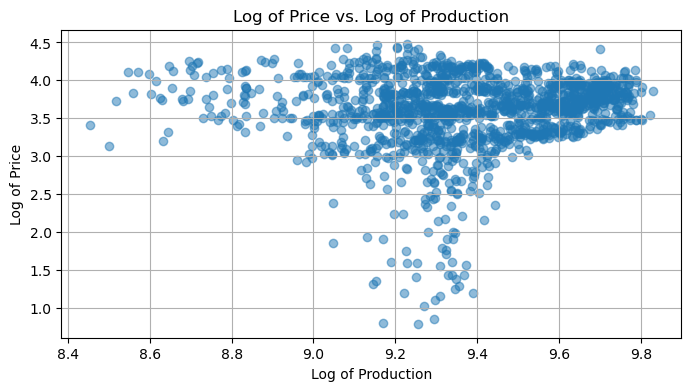

In [11]:
# Price vs. Production Plot
plt.figure(figsize=(8, 4))
plt.scatter (df ['log_prod'], df['log_price'], alpha=0.5)
plt.title('Log of Price vs. Log of Production')
plt.xlabel('Log of Production')
plt.ylabel('Log of Price')
plt.grid(True)
plt.show()

Similar to the previous plot depicting price against consumption, there is significant dispersion among the data points, indicating variability in the relationship between electricity price and production. There is a dense cluster of data points observed within the mid-range of production, suggesting that the majority of electricity production occurs within these levels. Just as it was observed in the graph above, as we increase production, the plot thickens and has a dense cluster within the range of 3.0 to 4.0. In conclusion, there seems to be less variability in price at the higher production levels compared to the lower production levels. This could suggest that prices tend to stabilize when production is high, possibly due to economies of scale or a better match between supply and demand.

# Question 2

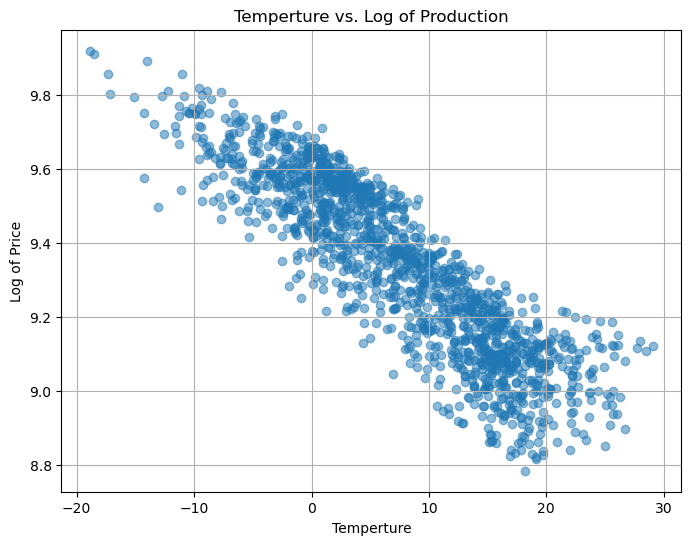

In [12]:
# Price vs. Production Plot
plt.figure(figsize= (8, 6))
plt.scatter (df["temp_osl"], df["log_cons"], alpha=0.5)
plt.title("Temperture vs. Log of Production")
plt.xlabel("Temperture")
plt.ylabel('Log of Price')
plt.grid(True)
plt.show ()

There is a notable trend where higher temperatures are associated with lower electricity prices.  This is particularly evident within the temperature range spanning approximately -10°C to 20°C. As temperatures approach the higher end of the spectrum (above 20°C), the decline in log prices becomes less pronounced. An example would be during summer where the prices of electricty decrease in response to decreased demand (mainly because of decreased heating demand). On the other hand, as the temperature decreases overtime, the log of price starts to increase, mainly because of increased electricity demand for heating purposes in winter season. 

In conclusion, there is a negative correlation between temperature and the log of electricity prices, aligning with the anticipated pattern where colder temperatures heighten the demand for electricity for heating, thus influencing prices. Nevertheless, as temperatures rise, the impact of temperature on prices appears to diminish, indicating that the cooling demand during warmer periods may not exert as much influence as heating demand during colder seasons. Alternatively, it is also possible that the market possesses adequate supply to accommodate the heightened demand during warmer temperatures without triggering notable price fluctuations.


# Question 2.2 

In [13]:
# Creating the "heatd" variable
df["heatd"] = 17 - df["temp_osl"]
df["heatd"] = df["heatd"].apply(lambda x: x if x > 0 else 0)

# Question 3

In [14]:
average_consumption_by_day = df .groupby (["day"]) [['cons']].mean()
average_consumption_by_day

,cons
day,
1,11987.052632
2,12023.368421
3,12132.928230
4,12003.636364
5,12096.636364
6,10787.502392
7,10126.253589


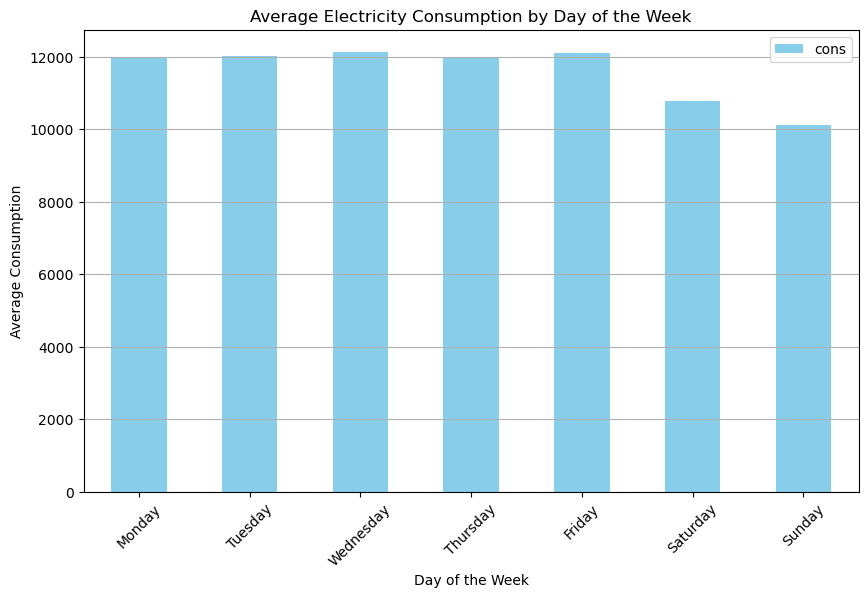

In [15]:
average_consumption_by_day.plot (kind='bar', figsize=(10, 6), color= "skyblue")
plt. title("Average Electricity Consumption by Day of the Week")
plt.xlabel('Day of the Week')
plt.ylabel("Average Consumption")
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday'], rotation = 45)
plt.grid(axis="y")
plt. show()

From the graph, it can be observed that electricity consumption is higher during the weekdays, with a peak on Wednesday and Friday, and then significantly drops during the weekend. This pattern is attributed to a typical work-week activity, where commercial and industrial electricity demand would be higher on weekdays, especially midweek, and decreases on weekends when many businesses shut down and there is less economic activity going on.


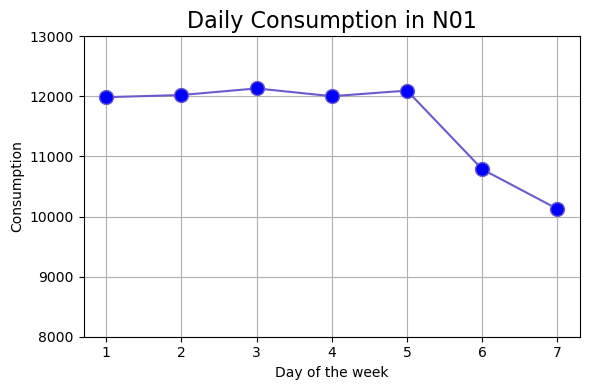

In [16]:
fig, ax = plt.subplots(figsize =(6,4))
ax.set_title('Daily Consumption in N01', fontsize=16)
ax.plot(average_consumption_by_day['cons'], c='slateblue',marker='o',markerfacecolor='blue', markersize=10)
ax.set_xlabel('Day of the week') 
ax.set_ylabel('Consumption')
ax.set_ylim(8000,13000)
ax.grid(True)
fig.tight_layout()


The line plot gives a different visualization of the daily consumption plotted against the days of the week hence it tells the same story as the graph above. The line maintains a relatively steady trajectory from Monday to Friday which , suggests consistent consumption levels, before declining towards the weekend, notably on Sunday. Just as it was displayed in the bar graph above, saturday and sunday has a lower consumption level compared to the rest of the days of the week because of decreased economic activity like manufacturing. Sunday has the lowest consumption because it is usually considered a 'rest' day hence the majority of people do not work, which matches the big difference in electricity consumption. 
Even though the bar graph and line graph tell the same story, the line graphs portrays a better relationship.


# Question 4 

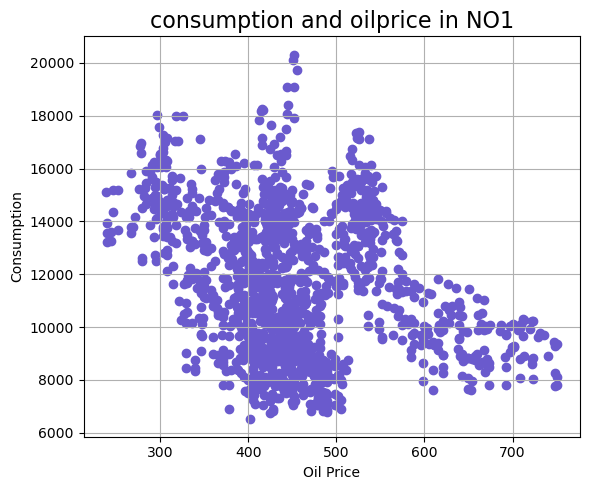

In [17]:
fig, ax = plt.subplots(figsize=(6,5))
ax.set_title ('consumption and oilprice in NO1', fontsize=16)
ax.scatter(df['p_oil'], df['cons'], c= 'slateblue')
ax.set_xlabel('Oil Price')
ax.set_ylabel('Consumption')
ax.grid(True)
fig.tight_layout()

The plot does not display a linear relationship between oil prices and consumption, which makes it difficult to conclude on the correlation. In this case it is really hard to tell if the price of oil is indeed a driver of consumption. From the graph we can observe that when oil prices are low, electricity usage tends to be high, implying that consumers are more inclined to use electricity when energy expenses are comparatively lower. As oil prices rise into the middle range, we observe a clustering of data points around the middle of the consumption spectrum. This clustering suggests a wider array of consumption levels across different price points, indicating a more evenly distributed range of consumption behaviors as oil prices reach moderate levels. However, as oil prices continue to increase beyond this midpoint, we see fewer data points clustered around a lower consumption range. This suggests a scenario where consumers may reduce electricity usage in response to heightened energy costs, opting for more conservative consumption patterns to manage expenses. 


# Question 5.1 
Plot actual reservoir filling and normal reservoir filling

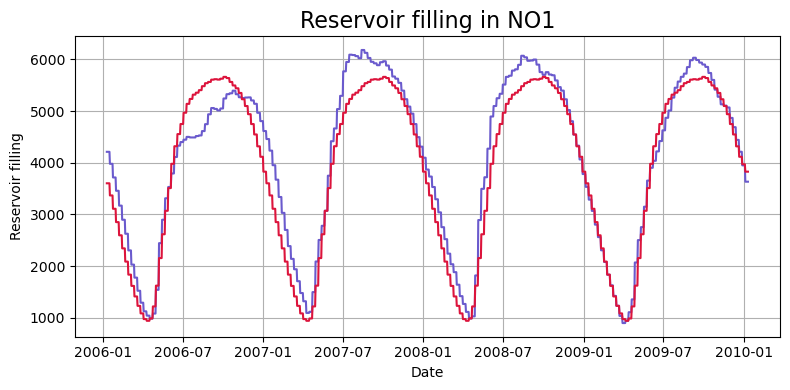

In [18]:
fig, ax = plt.subplots(figsize=(8,4))
ax.set_title ('Reservoir filling in NO1', fontsize=16)
ax.plot(df['res_level'], c= 'slateblue')
ax.plot(df['norm_level'], c= 'crimson')
ax.set_xlabel('Date')
ax.set_ylabel('Reservoir filling')
ax.grid(True)
fig.tight_layout()

The trends depicted by the lines exhibit recurring cycles, suggesting yearly fluctuations possibly influenced by seasonal changes in reservoir levels. These fluctuations might emerge from factors such as precipitation or snowmelt. Typically, both lines reach their highest points simultaneously, likely during periods of abundant rainfall leading to reservoir replenishment. Conversely, they both hit their lowest points around the same time annually, possibly during drier periods characterized by reduced rainfall and increased water consumption or evaporation rates.

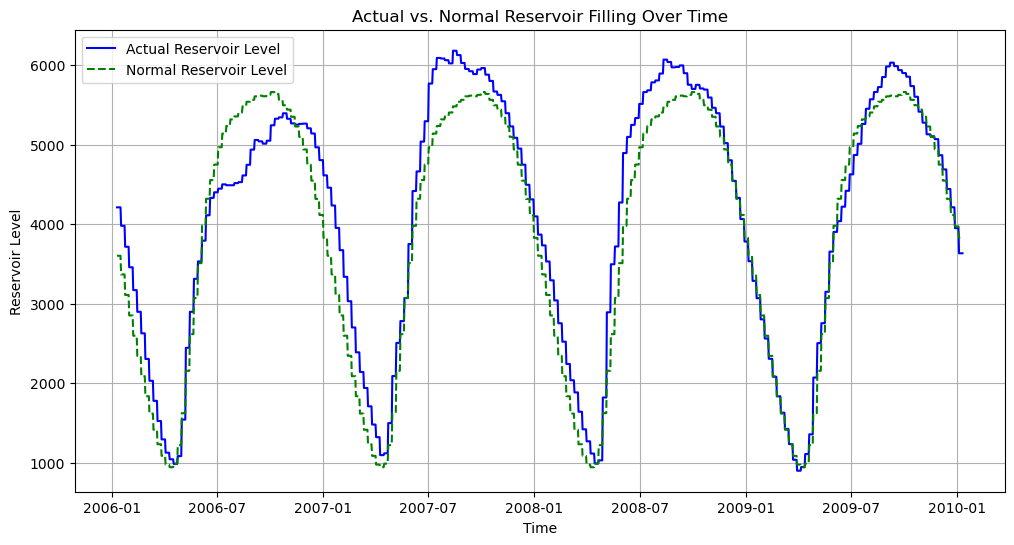

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['res_level'], label='Actual Reservoir Level', color='blue') 
plt.plot(df['time'], df['norm_level'], label='Normal Reservoir Level', color='green', linestyle='--') 
plt.title('Actual vs. Normal Reservoir Filling Over Time')
plt.xlabel('Time')
plt.ylabel('Reservoir Level')
plt.legend()
plt. grid(True)
plt.show()

By observing the difference between the "Actual" and "Normal" levels, it can be noted that the actual levels generally follow the normal levels closely, although there are intermittent periods when the actual level deviates from the normal. This data is significant for water resource administration as it identifies periods of possible water abundance or scarcity, guiding choices on water distribution, conservation strategies, and other management interventions.

# Question 5.2 

In [20]:
df['rshort'] = df ['res_level'] / df ['norm_level']

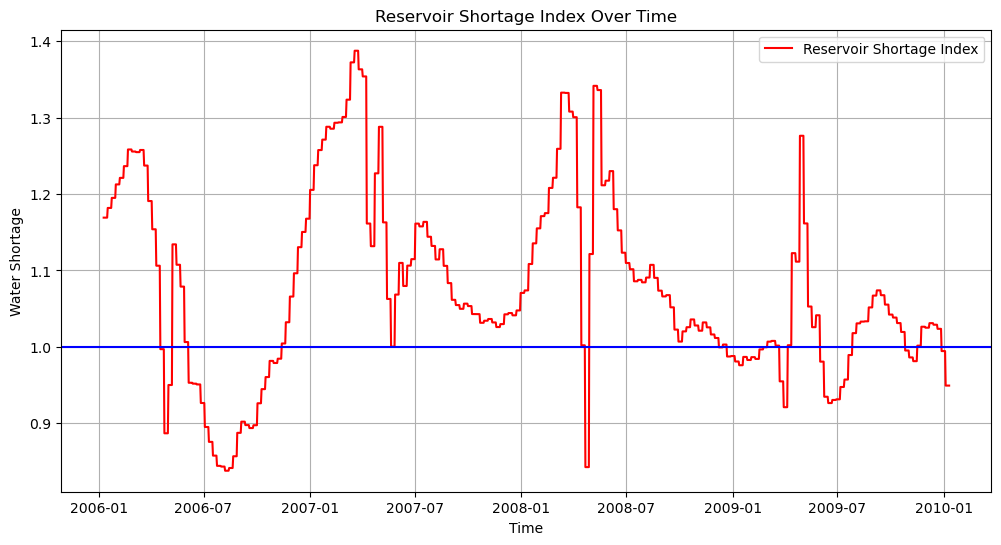

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['rshort'], label='Reservoir Shortage Index', color='red')
plt.title('Reservoir Shortage Index Over Time')
plt.xlabel('Time')
plt.axhline(y=1, c='blue') 
plt.ylabel('Water Shortage') 
plt.legend()
plt.grid(True)
plt.show() 

The graph illustrates periods where the deficit index surpasses 1.0, suggesting periods when the reservoir contained less water than expected or required. These peaks, exceeding the baseline, likely raise concerns for water resource management, indicating potential strain on water reserves. Fluctuations and spikes in the index may result from seasonal shifts, rainfall discrepancies, heightened water usage, or other factors influencing reservoir levels. This visual depiction underscores the dynamic nature of reservoir water levels and the difficulty in sustaining a steady water supply over time.

# Question 5.3 

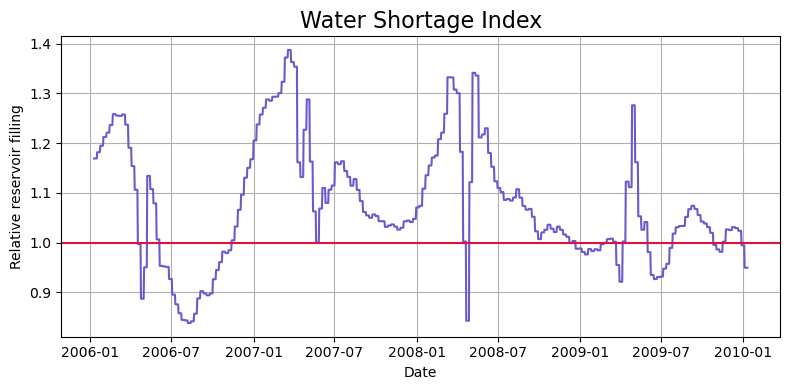

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title('Water Shortage Index', fontsize=16)
ax.plot(df['rshort'], c='slateblue')  
ax.axhline(y=1, c='crimson')
ax.set_xlabel('Date')
ax.set_ylabel('Relative reservoir filling')
ax.grid(True)
fig.tight_layout()
plt.show() 

By examining the fluctuations of the blue line, it becomes evident that the reservoir's filling level varies both above and below the standard level over time. There are noticeable sudden increases and decreases, implying swift changes in water levels. These fluctuations may stem from abrupt alterations in water input or extraction, or possibly from irregularities in recording or data inaccuracies.
Initially, the index predominantly remains above the standard level, indicating sufficient or surplus water levels. However, in the later years, particularly from around mid-2008 to mid-2009, there are more occurrences where the index drops below 1.0, suggesting more frequent or severe water shortages. These observed patterns could offer valuable insights into the reservoir's long-term water resource sustainability and prove beneficial for planning purposes among water managers and policymakers.


# Comparing reservior shortage and price 

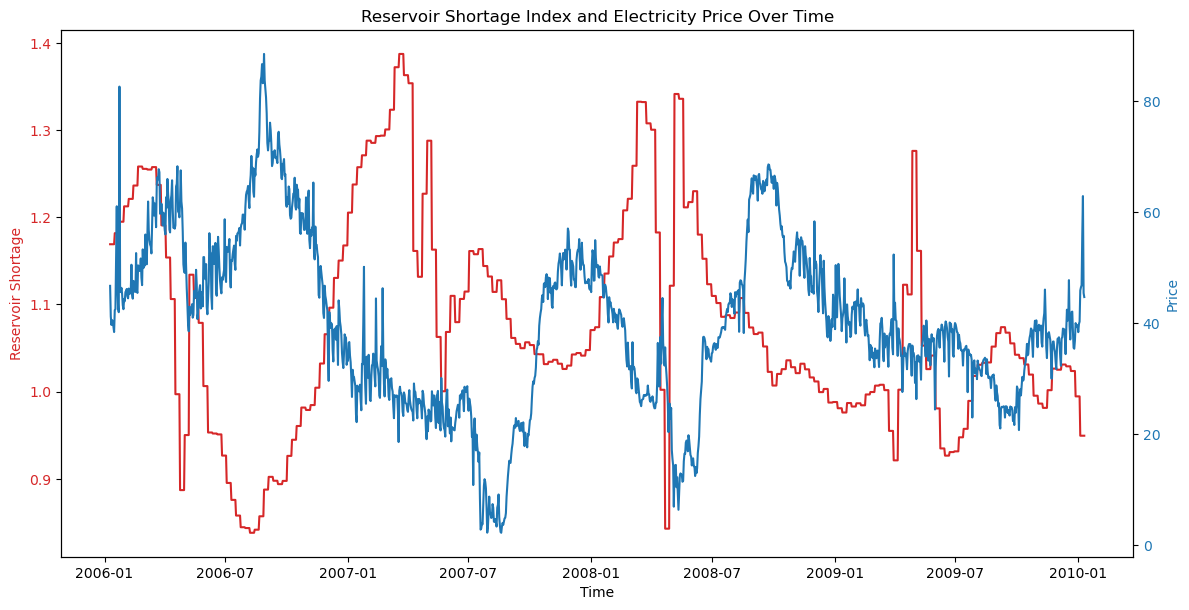

In [23]:

fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:red'

ax1.set_xlabel('Time')
ax1.set_ylabel('Reservoir Shortage', color=color)
ax1.plot(df['time'], df['rshort'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Price', color=color)
ax2.plot(df['time'], df['price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Reservoir Shortage Index and Electricity Price Over Time')
plt.show()


On average, the Reservoir Shortage Index and Electricity Price Over Time tend move in opposite directions as depicted in the graph. If the reservoir is utilized for generating hydroelectric power, decreased water levels may lead to diminished electricity production, possibly resulting in high prices due to scarcity. Peaks observed in the Reservoir Shortage Index, signaling water deficits, appear to coincide with spikes in electricity rates, indicating a correlation where water scarcity could influence both electricity supply and pricing. 

Conversely, there are instances where the two datasets diverge, suggesting the presence of additional factors impacting electricity prices independently of water levels.
The graph offers valuable insights into the interplay between natural resources and energy economics. It indicates that the availability of water in the reservoir can directly impact electricity market prices, which holds significance for energy stakeholders and policymakers. Moreover, it can serve as an illustration of how environmental factors can broadly influence economic conditions.


# Question 6.1 

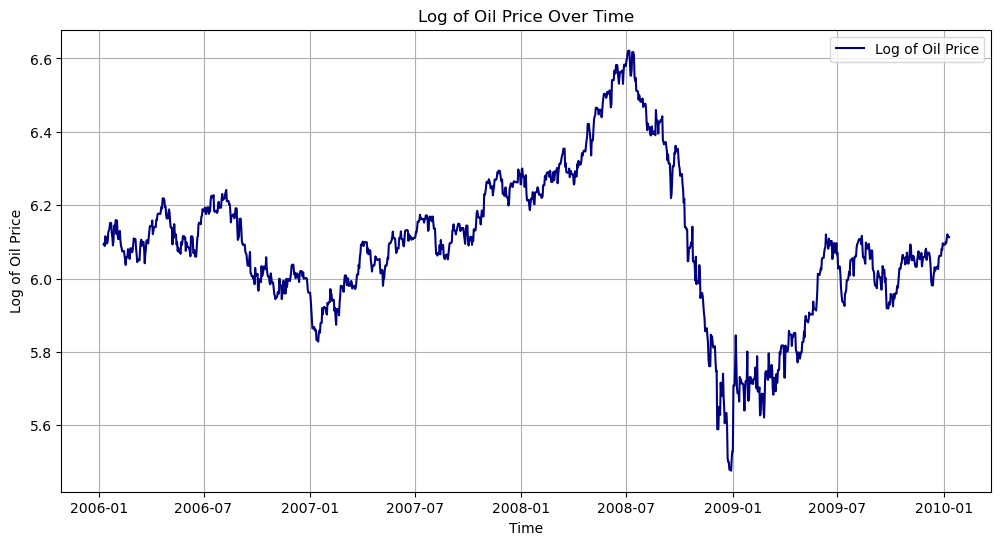

In [24]:
# Plotting for the log of oil price
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['ln_poil'], label='Log of Oil Price', color='navy')
plt.title('Log of Oil Price Over Time')
plt.xlabel('Time')
plt.ylabel('Log of Oil Price')
plt.legend()
plt.grid(True)
plt.show()

A distinct peak indicates a notable price surge, succeeded by a steep decline, signaling a significant drop. This peak likely corresponds to identifiable economic occurrences impacting oil prices, such as geopolitical shifts, supply and demand alterations, or market dynamics.
Following the sharp decline, the graph depicts a partial recovery in prices with ongoing fluctuations. These fluctuations may reflect market instability or reactions to economic updates, policy alterations, or other variables influencing the oil industry 
In essence, this graph offers insights into the stability and volatility of oil prices throughout the specified timeframe, serving as valuable information for economists, investors, and policymaker."


# Question 6.2

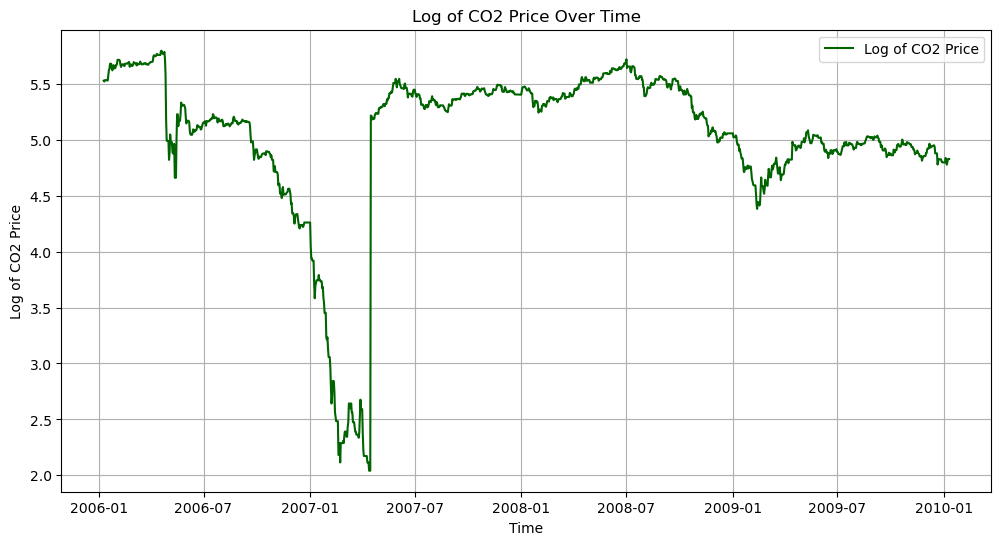

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['ln_pco2'], label='Log of CO2 Price', color='darkgreen')
plt.title('Log of CO2 Price Over Time')
plt.xlabel('Time')
plt.ylabel('Log of CO2 Price')
plt.legend()
plt.grid(True)
plt.show()

The graph displays several steep inclines and declines, with the most significant drop in CO2 price occurring post-2007, followed by a sharp decline to its lowest point before gradually rebounding and stabilizing. These fluctuations could stem from various factors such as policy shifts, economic dynamics, industry practices, or alterations in the supply and demand for carbon credits.
Towards the latter part of the timeline, the CO2 price stabilizes to some extent but still exhibits fluctuations. This stabilization could be attributed to market adjustments in response to earlier volatility or regulatory interventions impacting the carbon markees.


In conclusion, Norway has a variable energy production of electricity which is influenced significantly by CO2 prices and high Brent prices across Europe. These factors contribute to making Norwegian electricity supply increasingly competitive within the European market. The CO2 prices have a pronounced impact on thermal production throughout Europe, directly influencing the cost dynamics and competitiveness of various energy sources. Leveraging its surplus electricity production capacity, Norway stands positioned to capitalize on favorable market conditions by selling excess electricity to meet demand in the broader European marketplace. This strategic advantage underscores Norway's role as a significant player in the regional energy landscape, offering reliable and sustainable electricity resources to support European energy needs while simultaneously contributing to its own economic growth. 

# Question 7

# Estimating the OLS for the demand function 

In [26]:
#OLS
olsmod = iv. IV2SLS.from_formula(formula ='log_cons ~ 1 + log_price + heatd + ln_poil + dwkday', data=df)
olsdres = olsmod.fit (cov_type='unadjusted')
print(olsdres)

                            OLS Estimation Summary                            
Dep. Variable:               log_cons   R-squared:                      0.8857
Estimator:                        OLS   Adj. R-squared:                 0.8854
No. Observations:                1463   F-statistic:                 1.134e+04
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:30:03   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      8.8280     0.0689     128.12     0.0000      8.6930      8.9631
log_price     -0.0200     0.0043    -4.6868     0.00

# IV method for the demand function 

In [27]:
# IV model for the demand function
ivrdmod = iv.IV2SLS.from_formula(formula='log_cons ~ 1 + heatd + ln_poil + dwkday + [log_price ~ rshort + ln_pco2]', data= df)
ivrdres = ivrdmod.fit (cov_type='unadjusted')
print(ivrdres)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               log_cons   R-squared:                      0.8842
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8839
No. Observations:                1463   F-statistic:                 1.119e+04
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:30:03   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      8.8784     0.0718     123.72     0.0000      8.7378      9.0191
heatd          0.0273     0.0003     87.502     0.00

The estimated parameters for both the OLS and IV methods are almost the same because the difference is quite small hence they both lead to the same conclusion. This means that estimating the demand function using either of the models actually drives to the same conclusion. 

# Estimating the OLS for the Supply function 

In [28]:
olssmod = iv.IV2SLS.from_formula(formula = "log_price ~ 1 + rshort + ln_poil +ln_pco2 + log_cons", data =df)
olssres = olssmod.fit(cov_type = "unadjusted")
print(olssres)

                            OLS Estimation Summary                            
Dep. Variable:              log_price   R-squared:                      0.2936
Estimator:                        OLS   Adj. R-squared:                 0.2917
No. Observations:                1463   F-statistic:                    608.13
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:30:04   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -4.6927     0.6839    -6.8622     0.0000     -6.0331     -3.3524
rshort        -2.3384     0.1068    -21.891     0.00

# IV method for the supply function 

In [29]:
ivrsmod = iv.IV2SLS.from_formula(formula = "log_price ~ 1 + rshort + ln_poil +ln_pco2 + [log_cons ~ heatd + dwkday]", data =df)
ivrsres = ivrsmod.fit(cov_type = "unadjusted")
print(ivrsres)

                          IV-2SLS Estimation Summary                          
Dep. Variable:              log_price   R-squared:                      0.2868
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2849
No. Observations:                1463   F-statistic:                    681.70
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:30:04   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -6.9129     0.7280    -9.4959     0.0000     -8.3397     -5.4861
rshort        -2.4685     0.1083    -22.803     0.00

The results generated by the OLS results and the IV-2SLS method have a slight difference in terms of the parameter estimators. However, the difference is quite minimal hence we can conlcude that regardless of which method we pick, the conclusion is the same. 

# First stage and test for demand

In [30]:
# First stage equation for demand 
fsdmod = smf.ols(formula = "log_price ~ heatd + dwkday + ln_poil + rshort +ln_pco2", data= df)
fsdres = fsdmod.fit(cov_type = "HC3")
fsdtab = pd.DataFrame({ "b" : round(fsdres.params, 4),
"se" : round(fsdres.bse, 4),
"t" : round(fsdres.tvalues, 2),
"pval" : round(fsdres.pvalues, 4)})
print(fsdtab)

                b      se      t    pval
Intercept  2.3669  0.3094   7.65  0.0000
heatd      0.0291  0.0020  14.54  0.0000
dwkday     0.1056  0.0242   4.37  0.0000
ln_poil    0.6108  0.0695   8.78  0.0000
rshort    -2.3931  0.1267 -18.89  0.0000
ln_pco2   -0.0566  0.0158  -3.58  0.0003


# 7.1.1 Test for weak instruments for demand

In [31]:
# Do an F-test of weak instruments
wihyp = ["rshort = 0", "ln_pco2 = 0"]
witest = fsdres.f_test(wihyp)
print("Test for weak instruments")
print("F-stat : {}". format(witest.statistic))
print("p-value : {}". format(witest.pvalue))

Test for weak instruments
F-stat : 350.8439676294399
p-value : 4.197274056056065e-125


This test is used to assess the strength of the instruments used in the IV regression. The null-hypothesis states that the instruments are weak. The p-value (4.197274056056065e-125) is relatively small and less than the level of significance (0.05) hence we reject the null hypothesis. This means that the instruments are not weak, and are sufficiently correlated with the endogenous variables. We can conclude that the instruments are suitable for adressing endogeneity in the regression model. 

On the other hand, the high value of the F-Statistic suggests stronger instruments, which means that the instruments are more correlated with the endogenous variables in the model.  

# First stage equation for supply

In [32]:
fssmod = smf.ols(formula = "log_prod ~ heatd + dwkday + ln_poil + rshort +ln_pco2", data= df)
fssres = fssmod.fit(cov_type = "HC3")
fsstab = pd.DataFrame({ "b" : round(fsdres.params, 4),
"se" : round(fsdres.bse, 4),
"t" : round(fsdres.tvalues, 2),
"pval" : round(fsdres.pvalues, 4)})
print(fsstab)

                b      se      t    pval
Intercept  2.3669  0.3094   7.65  0.0000
heatd      0.0291  0.0020  14.54  0.0000
dwkday     0.1056  0.0242   4.37  0.0000
ln_poil    0.6108  0.0695   8.78  0.0000
rshort    -2.3931  0.1267 -18.89  0.0000
ln_pco2   -0.0566  0.0158  -3.58  0.0003


# 7.1.2 Test for weak instruments for Supply

In [33]:
# Do an F-test of weak instruments
wihyp = ["heatd = 0", "dwkday = 0"]
witest = fsdres.f_test(wihyp)
print("Test for weak instruments")
print("F-stat : {}". format(witest.statistic))
print("p-value : {}". format(witest.pvalue))

Test for weak instruments
F-stat : 110.01919476716894
p-value : 3.167414153330356e-45


This test is used to assess the strength of the instruments used in the IV regression. The null-hypothesis states that the instruments are weak. The p-value (3.167414153330356e-45) is relatively small and less than the level of significance (0.05) hence we reject the null hypothesis. This means that the instruments are not weak, and are sufficiently correlated with the endogenous variables. We can conclude that the instruments are suitable for adressing endogeneity in the regression model. 

On the other hand, the high value of the F-Statistic (110.0192) suggests stronger instruments, which means that the instruments are more correlated with the endogenous variables in the model.  

# 7.2 Test for Endogeneity

In [34]:
# Demand equation results in ivrdres

ivrdres.wooldridge_regression

Wooldridge's regression test of exogeneity
H0: Endogenous variables are exogenous
Statistic: 7.6205
P-value: 0.0058
Distributed: chi2(1)
WaldTestStatistic, id: 0x1ea5ac0fa50

The null hypothesis states that the endogenous variables in the model are not correlated with the error term (exogenous).
The p-value (0.0058) is less than the level of significance (0.005) hence we reject the null hypothesis and conclude that the endogenous variables are likely correlated with the error term. Therefore based on this test, there is evidence indicating the presence of endogeneity and it needs to be addressed.






In [35]:
# Supply equation results in ivrdres

ivrsres.wooldridge_regression

Wooldridge's regression test of exogeneity
H0: Endogenous variables are exogenous
Statistic: 91.4719
P-value: 0.0000
Distributed: chi2(1)
WaldTestStatistic, id: 0x1ea5ac92dd0

The null hypothesis states that the endogenous variables in the model are not correlated with the error term (exogenous). The p-value (0.0000) is less than the level of significance (0.005) hence we reject the null hypothesis and conclude that the endogenous variables are likely correlated with the error term. Therefore based on this test, there is evidence indicating the presence of endogeneity and it needs to be addressed

# 7.3 Test for Validity

In [36]:
# Demand equation results in ivrdres

ivrdres.wooldridge_overid

Wooldridge's score test of overidentification
H0: Model is not overidentified.
Statistic: 2.8580
P-value: 0.0909
Distributed: chi2(1)
WaldTestStatistic, id: 0x1ea5ac9f090

The test of overidentification evaluates the validity of the instruments used in the model. The null hypothesis states that the model is not overidentified, meaning that the number of instruments used matches the number of endogenous variables appropriately.  The p-value (0.0909) is greater than the level of significance (0.05), hence we fail to reject the null hypothesis and conclude that there isnt enough evidence to suggest that the model is overidentified.

In [37]:
# Supply equation results in ivrdres

ivrsres.wooldridge_overid

Wooldridge's score test of overidentification
H0: Model is not overidentified.
Statistic: 5.5257
P-value: 0.0187
Distributed: chi2(1)
WaldTestStatistic, id: 0x1ea5ac9c090

The null hypothesis states that the model is not overidentified, meaning that the number of instruments used matches the number of endogenous variables appropriately. The p-value (0.0187) is less than the level of significance (0.05), hence we reject the null hypothesis. There is evidence to conclude that the model is overidentified. The results therefore suggest that there are more instruments relative to the number of endogenous variables. This could result in potential inefficiency in estimation or biased results. It would therefore be recommended to revisit the instruments selection process and potentially refine the instrument set to improve the validity of the IV regression model.  

# 7.4.1 Test for heteroskedasticity for Demand

In [38]:
#testing for heteroskedosticity for demand
df['ud_sqr'] = ivrdres.resids ** 2
bphmod = smf.ols (formula = "ud_sqr ~ heatd + dwkday + ln_poil + rshort + ln_pco2", data = df)
bphres = bphmod. fit ()
print ("Breusch-Pagan F-test: {}".format(round(bphres.fvalue,4)))
print(" p-value: {}".format(round(bphres. f_pvalue, 4)))

Breusch-Pagan F-test: 5.9464
 p-value: 0.0


The null hypothesis of the test states that there is homoskedasticity (constant variance). The p-value of 0.0 is less than the level of significance (0.05) hence we reject the null hypothesis and conclude that there is heteroskedasticity in the dataset. This means that the variance of the error term is not constant across the observations, which violates one of the assumptions of linear regression. This can therefore be addressed by the use of robust standard errors in order to ensure validity of the regression results. In this case we  will use the GMM to forecast the demand model because the OLS validates one of the assumptions.

# 7.4.2 Test for heteroskedosticity for Supply 

In [39]:
# test for heteroskedosticity for supply
df['us_sqr'] = ivrsres.resids ** 2
bphmod = smf.ols (formula = "us_sqr ~ heatd + dwkday + ln_poil + rshort +ln_pco2", data = df)
bphres = bphmod. fit ()
print ("Breusch-Pagan F-test: {}".format(round(bphres.fvalue,4)))
print(" p-value: {}".format(round(bphres. f_pvalue, 4)))

Breusch-Pagan F-test: 22.2242
 p-value: 0.0


The results of Breusch-Pagan test lead us to the same conclusion as the demand model above. The p-value (0.0) is less than the level of significance (0.05) therefore we reject the null-hypothesis and conclude that there is heteroskedasticity. In the  presence of heteroskedasticity, the OLS estimates remain unbiased, but they are no longer the best linear unbiased estimators (BLUE), because they are not efficient. Therefore, in order to address this issue, we may actually prefer to use the generalized method of moments (GMM) as an alternative estimation technique.

# The GMM model for Demand 

In [40]:
# GMM Demand
gmmdmod = iv.IVGMM.from_formula(formula = "log_cons ~ 1 + heatd + ln_poil + dwkday + [log_price ~ rshort + ln_pco2]",weight_type = "robust", data=df)
gmmdres = gmmdmod.fit(cov_type = "robust")
print(gmmdres.summary)

                          IV-GMM Estimation Summary                           
Dep. Variable:               log_cons   R-squared:                      0.8844
Estimator:                     IV-GMM   Adj. R-squared:                 0.8841
No. Observations:                1463   F-statistic:                    8912.3
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:30:05   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      8.8721     0.0678     130.88     0.0000      8.7393      9.0050
heatd          0.0273     0.0003     79.662     0.00

In [41]:
##Test for valid instruments

print(gmmdres.j_stat)

H0: Expected moment conditions are equal to 0
Statistic: 2.8580
P-value: 0.0909
Distributed: chi2(1)


In [42]:
# Summary of demand results
print(iv.compare({"OLS": olsdres, "IV": ivrdres, "GMM": gmmdres}))

                        Model Comparison                        
                                OLS             IV           GMM
----------------------------------------------------------------
Dep. Variable              log_cons       log_cons      log_cons
Estimator                       OLS        IV-2SLS        IV-GMM
No. Observations               1463           1463          1463
Cov. Est.                unadjusted     unadjusted        robust
R-squared                    0.8857         0.8842        0.8844
Adj. R-squared               0.8854         0.8839        0.8841
F-statistic               1.134e+04      1.119e+04        8912.3
P-value (F-stat)             0.0000         0.0000        0.0000
==================     ============   ============   ===========
Intercept                    8.8280         8.8784        8.8721
                           (128.12)       (123.72)      (130.88)
log_price                   -0.0200        -0.0387       -0.0374
                         

The p-values for all three estimators are extremely low (0.0000), indicating that the models are highly statistically significant. On the other hand, the coefficients for the independent variables (intercept, log_price, heatd, ln_poil, dwkday) are consistent across the three estimation methods, with the t-statistics varying slightly.


From the results in 7.2 and 7.4 above, it was concluded that there is a presence of both endogeneity and heteroskedasticity in the model. This means that the coefficents estimated using OLS are inconsistent, thereby making the IV methods (IV-2SLS or IV-GMM) a better option in this case. These methods are preferred because they can provide consistent estimates in the presence of endogeneity by using Instrumental variables. Among these, GMM is recommended due to its robust covariance estimator, which can handle heteroskedasticity in the data. In conclusion, the GMM is a better estimator because it estimates parameters in the presence of heteroskedasticity or endogeneity thereby giving us more accurate and consistent results. 

# GMM Model for Supply 

In [43]:
# GMM Supply
gmmsmod = iv.IVGMM.from_formula(formula = "log_price ~ 1 + rshort + ln_pco2 + ln_poil + [log_prod ~ heatd + dwkday]",
weight_type = "robust", data=df)
gmmsres = gmmsmod.fit(cov_type = "robust")
print(gmmsres.summary)

                          IV-GMM Estimation Summary                           
Dep. Variable:              log_price   R-squared:                      0.1659
Estimator:                     IV-GMM   Adj. R-squared:                 0.1636
No. Observations:                1463   F-statistic:                    680.29
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:30:06   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -4.7572     0.8328    -5.7126     0.0000     -6.3894     -3.1250
rshort        -2.3540     0.1362    -17.280     0.00

In [44]:
#Test for valid intruments
print(gmmsres.j_stat)

H0: Expected moment conditions are equal to 0
Statistic: 60.4939
P-value: 0.0000
Distributed: chi2(1)


In [45]:
#Summary of supply results
print(iv.compare({"OLS": olssres, "IV": ivrsres, "GMM": gmmsres}))

                        Model Comparison                        
                                OLS             IV           GMM
----------------------------------------------------------------
Dep. Variable             log_price      log_price     log_price
Estimator                       OLS        IV-2SLS        IV-GMM
No. Observations               1463           1463          1463
Cov. Est.                unadjusted     unadjusted        robust
R-squared                    0.2936         0.2868        0.1659
Adj. R-squared               0.2917         0.2849        0.1636
F-statistic                  608.13         681.70        680.29
P-value (F-stat)             0.0000         0.0000        0.0000
==================     ============   ============   ===========
Intercept                   -4.6927        -6.9129       -4.7572
                          (-6.8622)      (-9.4959)     (-5.7126)
rshort                      -2.3384        -2.4685       -2.3540
                         

The OLS estimator is consistent and efficient if the models assumptions like linearity, independence of errors, homoskedasticity and no endogeneity hold true. However, in this case OLS is biased since the assumptions of both homoskedasticity and endogeneity are violated. 

The IV-2SLS estimator in this model is seen to produce slightly different coefficient estimates compared to OLS, which could indicate the presence of endogeneity issues and the necessity for a more robust estimation technique. The IV-GMM is another method used to address endogeneity by estimating the parameters based on moment conditions. This method is prefered when there are mosre instruments than endogenous regressors. In this case, IV-GMM provides further adjustments to the coefficient estimates, which might be necessary for addressing any remaining endogeneity concerns not adequately addressed by IV-2SLS.

# Question 8

# 8.1 Demand 

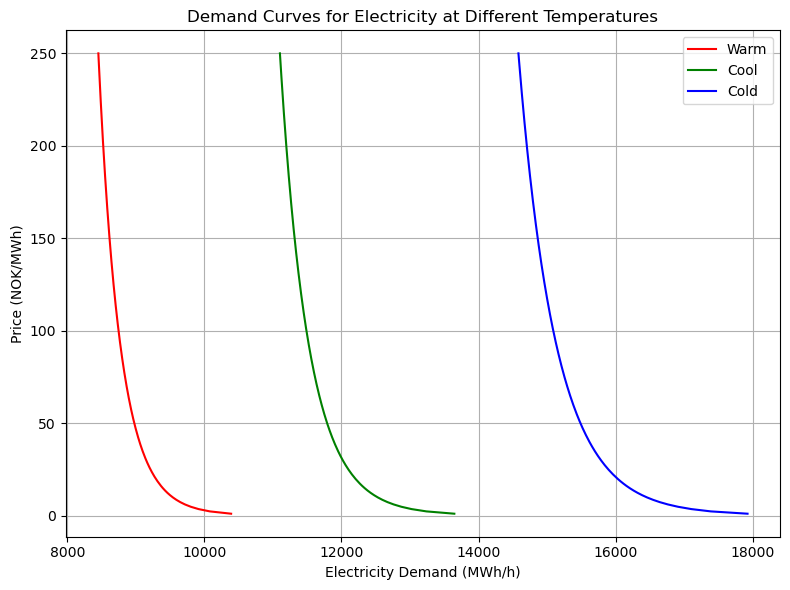

In [46]:

dbeta = gmmdres.params

# Setting up scenario parameters
oil_price = 500  # Oil price in NOK
co2_price = 250  # CO2 permits price in NOK
ln_oil_price = np.log(oil_price)  # Log-transformed oil price
ln_co2_price = np.log(co2_price)  # Log-transformed CO2 price

# Calculating the demand at different prices for various temperature conditions
prices = np.linspace(1, 250, 200)  # Range of prices
ln_prices = np.log(prices)  # Log-transformed prices for the model

# Calculating demands for different scenarios
warm = np.exp(dbeta['Intercept'] + dbeta['log_price']*ln_prices + dbeta['dwkday'] + dbeta['ln_poil']*ln_oil_price)
cool = np.exp(dbeta['Intercept'] + dbeta['heatd']*10 + dbeta['log_price']*ln_prices + dbeta['dwkday'] + dbeta['ln_poil']*ln_oil_price)
cold = np.exp(dbeta['Intercept'] + dbeta['heatd']*20 + dbeta['log_price']*ln_prices + dbeta['dwkday'] + dbeta['ln_poil']*ln_oil_price)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Swapping the axes: now y-axis is for demand and x-axis is for price
ax.plot(warm, prices, label='Warm', color='red')
ax.plot(cool, prices, label='Cool', color='green')
ax.plot(cold, prices, label='Cold', color='blue')

# Setting labels and titles
ax.set_ylabel('Price (NOK/MWh)')
ax.set_xlabel('Electricity Demand (MWh/h)')
ax.set_title('Demand Curves for Electricity at Different Temperatures')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The red curve, labeled "Warm," illustrates the electricity demand during warmer temperatures. It starts with a higher price for a lower demand and then sharply declines. This could suggest that in warmer weather, electricity initially costs more but decreases as demand goes down, possibly due to reduced heating needs or improved efficiency of air conditioning systems. A good example would be during the summer where people demand less electricity for heating hence the prices decrease. 

The green curve, labeled "Cool," depicts slightly higher demand compared to the "Warm" temperatures. This may indicate that during cooler temperatures, electricity is primarily used for heating, leading to increased demand. However, factors such as higher supply or lower production costs could also contribute to the lower price despite the heightened demand.

The blue curve, labeled "Cold" displays even higher demand at higher prices. It might signify a period like winter where the demand for electricity for cooling systems is high hence the price also tends to increase. 

Overall, these curves demonstrate how electricity demand fluctuates with temperature thereby impacting price. Warmer conditions lead to lower demand for electricity, while cooler conditions maintain a steadier demand and finally colder periods with an increased demand. 

# 8.2 Supply 

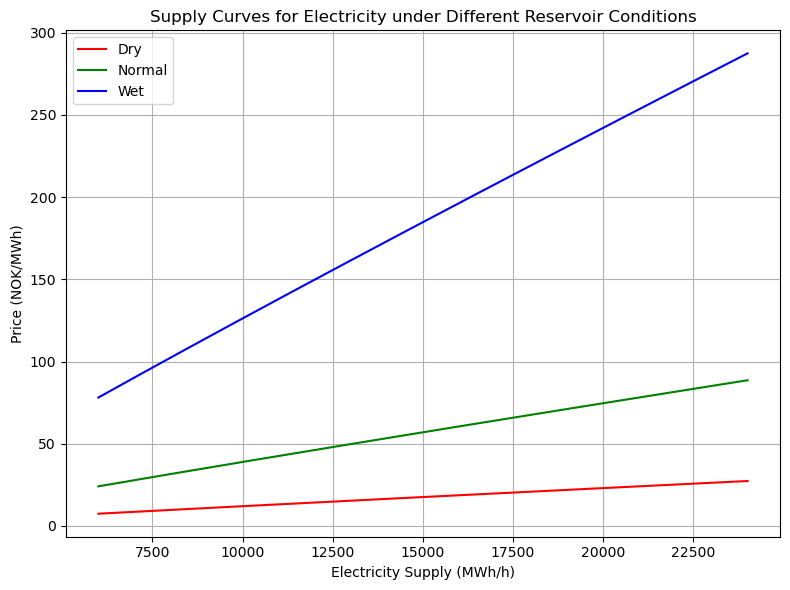

In [50]:
# Use the GMM model parameters for supply
sbeta = gmmsres.params

# Defining reservoir conditions with rshort values for dry, normal, and wet scenarios
rshort_values = {'Dry': 1.5, 'Normal': 1.0, 'Wet': 0.5}
# Corresponding colors for each scenario
colors = {'Dry': 'red', 'Normal': 'green', 'Wet': 'blue'}

# Generating a range of electricity supply quantities
supply_quantities = np.linspace(6000, 24000, 200)  
ln_supply_quantities = np.log(supply_quantities)  
# Plotting setup
fig, ax = plt.subplots(figsize=(8, 6))

# Calculating and plot supply curves for each reservoir condition
for condition, rshort in rshort_values.items():
    price = np.exp(sbeta['Intercept'] + sbeta['rshort'] * rshort +
                   sbeta['ln_pco2'] * ln_co2_price + sbeta['ln_poil'] * ln_oil_price +
                   sbeta['log_prod'] * ln_supply_quantities) 

    # getting the corresponding color of our choice
    color = colors[condition]
    ax.plot(supply_quantities, price, label=condition, color=color)

# Setting labels and titles
ax.set_xlabel('Electricity Supply (MWh/h)')
ax.set_ylabel('Price (NOK/MWh)')
ax.set_title('Supply Curves for Electricity under Different Reservoir Conditions')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The supply curves denote how different quantities are supplied under different reservior conditions. The red curve is a less steep supply curve during the "dry" period indicating that when reservoirs lack water, the electricity supply diminishes. Consequently, prices soar even with limited supply due to either higher electricity generation costs or the restricted capacity of hydroelectric power stations caused by water scarcity.
The green curve represents thehe "Normal" reservoir conditi which e displays higher electricity supply at lower prices compared to the dry condition. This signifies a balanced state where generation costs are typical, and water availability is adequate to meet demand without significant price hikes.

The blue curve illustrates the "Wet" condition, showcasing abundant electricity supply at even lower prices than the normal condition. This is likely because ample water, particularly in hydroelectric power generation, reduces production costs and enables increased electricity generation.

In summary, the graph illustrates how reservoir conditions directly impact electricity supply, consequently influencing prices. Wet conditions lead to abundant and cheaper electricity, while dry conditions result in scarcity and higher costs. The normal condition represents a middle ground between these two extremes.ature.

# 8.3 Market Equilibrium
warm weekday with normal reservoir filling

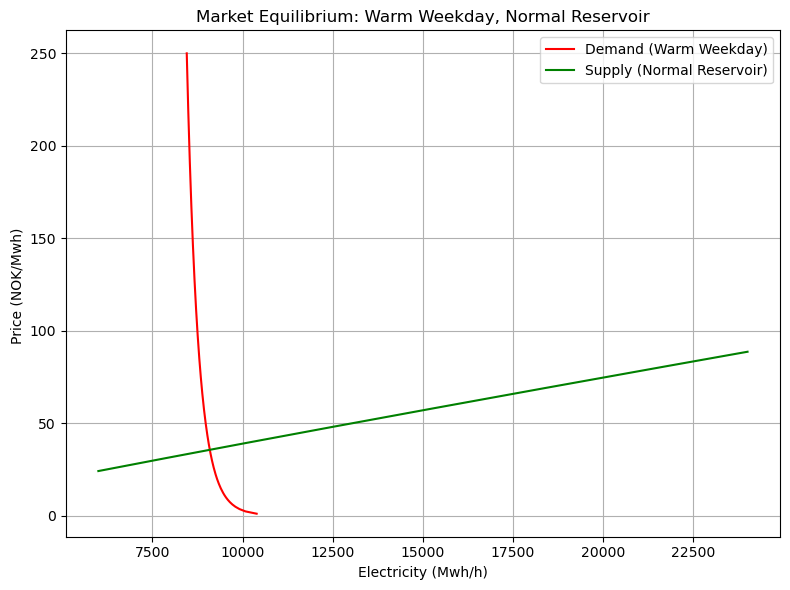

In [51]:
#Demand scenarios (warm,cool, cold) and Supply scenarios (Dry, Normal, Wet)
prices = np. linspace(1, 250, 200)
ln_prices = np. log(prices)
supply_quantities = np. linspace(6000, 24000, 200)
ln_supply_quantities = np. log(supply_quantities)

# Demand for a warm weekday
warm_demand = np.exp(dbeta[ 'Intercept'] + dbeta['log_price' ] * ln_prices + dbeta["dwkday"] + dbeta["ln_poil"] * ln_oil_price)

# Supply for normal reservoir filling
normal_supply_price = np. exp(sbeta['Intercept'] + sbeta['rshort'] * 1.0 + sbeta['ln_pco2'] * ln_co2_price + sbeta["ln_poil"]* ln_oil_price + sbeta["log_prod"] * ln_supply_quantities)

# Plotting
fig, ax = plt. subplots(figsize=(8, 6))

# Demand curve
ax. plot(warm_demand, prices, label = "Demand (Warm Weekday)", color ='red')

# Supply curve for normal reservoir
ax. plot(supply_quantities, normal_supply_price, label= 'Supply (Normal Reservoir)', color = 'green')

# Annotations and Labels
ax. set_xlabel( "Electricity (Mwh/h)")
ax.set_ylabel('Price (NOK/Mwh) ' )
ax.set_title( 'Market Equilibrium: Warm Weekday, Normal Reservoir')
ax. legend()
plt.grid (True)
plt.tight_layout()
plt.show()

This illustration depicts the equilibrium of the electricity market on a warm weekday with normal reservoir conditions. The red curve illustrates the demand for electricity, showing low demand at higher prices and diminishing demand as prices increase, a typical pattern reflecting consumer behavior where lower prices stimulate greater demand. The curve initially slopes steeply, indicating that even small price drops result in substantial increases in quantity demanded.

The green curve portrays the supply of electricity, which rises with price. Thie slopshowses that as prices increase, producers are inclined to supply more electricity to the marke

The intersection of the demand and supply curves denotes the market equilibrium. At  pointture, the quantity of electricity consumers desire matches the quantity suppliers are willing to provide, setting the price at the equilibrium point. The graph suggests a stable equilibrium price and quantity for electricity in this market, given the specified temperature and reservoir levels. This equilibrium price ensures that all electricity produced is sold, and consumers purchase all they desire at that price.

However, real-world market equilibriums are subject to various influences, including government regulations, market competition, and advancements in production technology. Furthermore, shifts in demand and supply may occur due to external factors like extreme weather events or fluctuations in fuel prices, consequently altering the equilibrium point.

# cold weekday withwater shortage

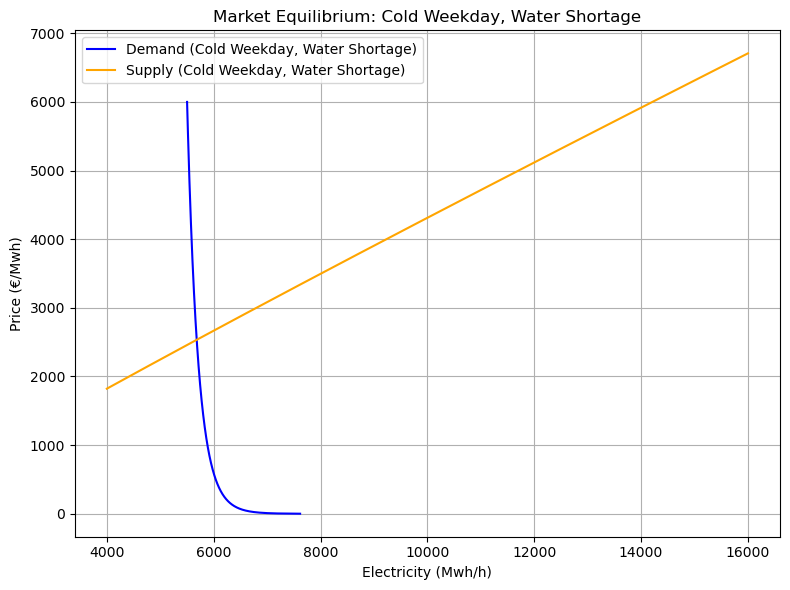

In [49]:
# Prices range
prices = np.linspace(1, 6000, 5000)
ln_prices = np.log(prices)

# Supply quantities range
supply_quantities = np.linspace(4000, 16000, 200)  # Adjusted for water shortage
ln_supply_quantities = np.log(supply_quantities)

# Demand for a cold weekday with water shortage
cold_demand = np.exp(dbeta['Intercept'] + dbeta['log_price'] * ln_prices + dbeta["dwkday"] * (-1) + dbeta["ln_poil"] * ln_oil_price)

# Supply for water shortage scenario
cold_supply_price = np.exp(sbeta['Intercept'] + sbeta['rshort'] * (-1.0) + sbeta['ln_pco2'] * ln_co2_price + sbeta["ln_poil"] * ln_oil_price + sbeta["log_prod"] * ln_supply_quantities)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Demand curve
ax.plot(cold_demand, prices, label="Demand (Cold Weekday, Water Shortage)", color='blue')

# Supply curve for water shortage scenario
ax.plot(supply_quantities, cold_supply_price, label='Supply (Cold Weekday, Water Shortage)', color='orange')

# Annotations and Labels
ax.set_xlabel("Electricity (Mwh/h)")
ax.set_ylabel('Price (€/Mwh)')
ax.set_title('Market Equilibrium: Cold Weekday, Water Shortage')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The graph above illustrates the market equilibrium for electricity during a cold weekday amid a water shortage. The demand curve (depicted in blue) and the supply curve (in orange) show the relationship between the price of electricity and the quantity supplied in megawatt-hours per hour (MWh/h).

The demand curve exhibits a steep slope, indicating that minor price fluctuations result in substantial changes in the quantity of electricity demanded. This steepness likely stems from the pressing need for heating during cold weather, rendering consumers less responsive to price adjustments.

Conversely, the supply cican be interpreted in the senseying that as prices rise, the quantity of electricity supplied increases. However, in the context of a water shortage, particularly affecting hydroelectric power generation, the production capacity is constrained. Consequently, the cost of producing additional electricity unincreasesa For a cold weekday with water shortage, the quantity supplied is less and the price is higher, when compared to the equilibrium graph above. The market clears where the electricity supplied is about 5,800 Mwh/h and the Price is 2,500. The big variation in the price from the graph above is a true reflection of how the market responds to a shortage. reration.